Number 24 - Alzheimer's Mice
Dataset Preview
   AD_Status Treatment Training Memory
1  Wild Type    Drug 1       12     10
2  Wild Type    Drug 1       15     12
3  Wild Type    Drug 1       13     13
4  Wild Type    Drug 1       12     10
5  Wild Type    Drug 1       14     13
6  Wild Type    Drug 2       15     13
7  Wild Type    Drug 2       17     13
8  Wild Type    Drug 2       16     14
9  Wild Type    Drug 2       17     15
10 Wild Type    Drug 2       14     11

Dimensions: 40 rows x 4 columns

 SECTION 1: CHECKING ASSUMPTIONS
Assumption 1: Continuous Dependent Variable
Both dependent variables – Training Day Errors and Memory Day Errors –
are measured as counts of maze errors (ratio-level, continuous).
This assumption is satisfied.

Assumption 2: Categorical Independent Variables
Factor A = AD_Status (2 levels: Wild Type, Transgenic).
Factor B = Treatment (4 levels: Drug 1, Drug 2, Drug 3, Drug 4).
Both are categorical, independent grouping variables.
This assumption is satisf

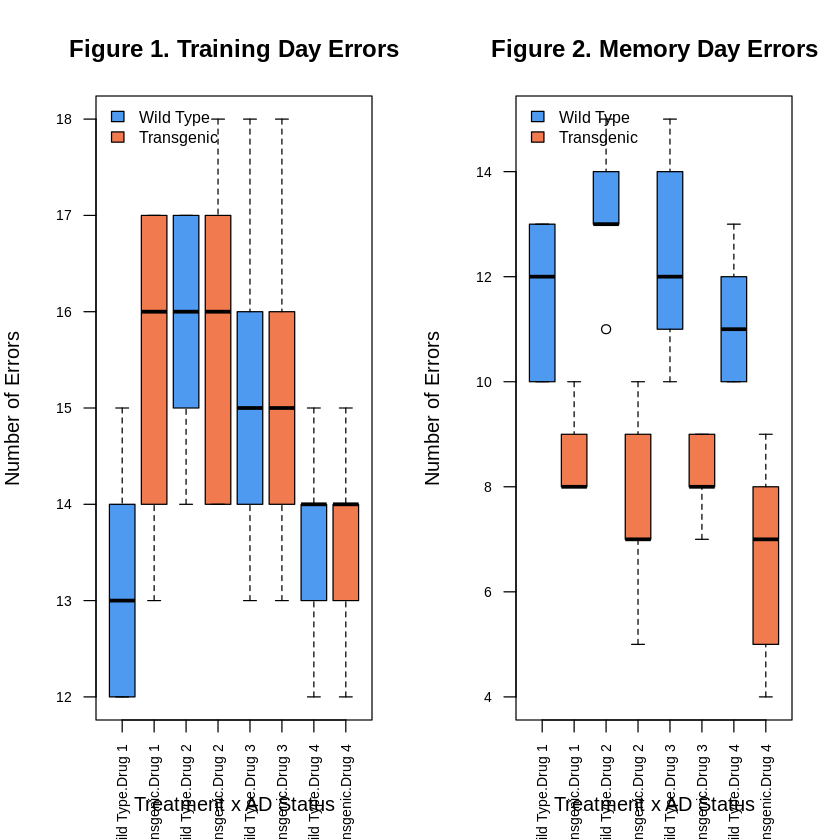

Assumption 6: Homogeneity of Variances (Levene's Test)

Levene's Test – Training Day: F(7, 32) = 0.659, p = 0.704
Levene's Test – Memory Day:   F(7, 32) = 1.568, p = 0.181

Remark (Training): Homogeneity of variances is satisfied (p > .05).
Remark (Memory):   Homogeneity of variances is satisfied (p > .05).

 SECTION 2: DESCRIPTIVE STATISTICS
Table 1. Descriptive Statistics – Training Day Errors
  AD_Status Treatment n Mean    SD    SE
  Wild Type    Drug 1 5 13.2 1.304 0.583
  Wild Type    Drug 2 5 15.8 1.304 0.583
  Wild Type    Drug 3 5 15.2 1.924 0.860
  Wild Type    Drug 4 5 13.6 1.140 0.510
 Transgenic    Drug 1 5 15.4 1.817 0.812
 Transgenic    Drug 2 5 15.8 1.789 0.800
 Transgenic    Drug 3 5 15.2 1.924 0.860
 Transgenic    Drug 4 5 13.6 1.140 0.510

Table 2. Descriptive Statistics – Memory Day Errors
  AD_Status Treatment n Mean    SD    SE
  Wild Type    Drug 1 5 11.6 1.517 0.678
  Wild Type    Drug 2 5 13.2 1.483 0.663
  Wild Type    Drug 3 5 12.4 2.074 0.927
  Wild Type    

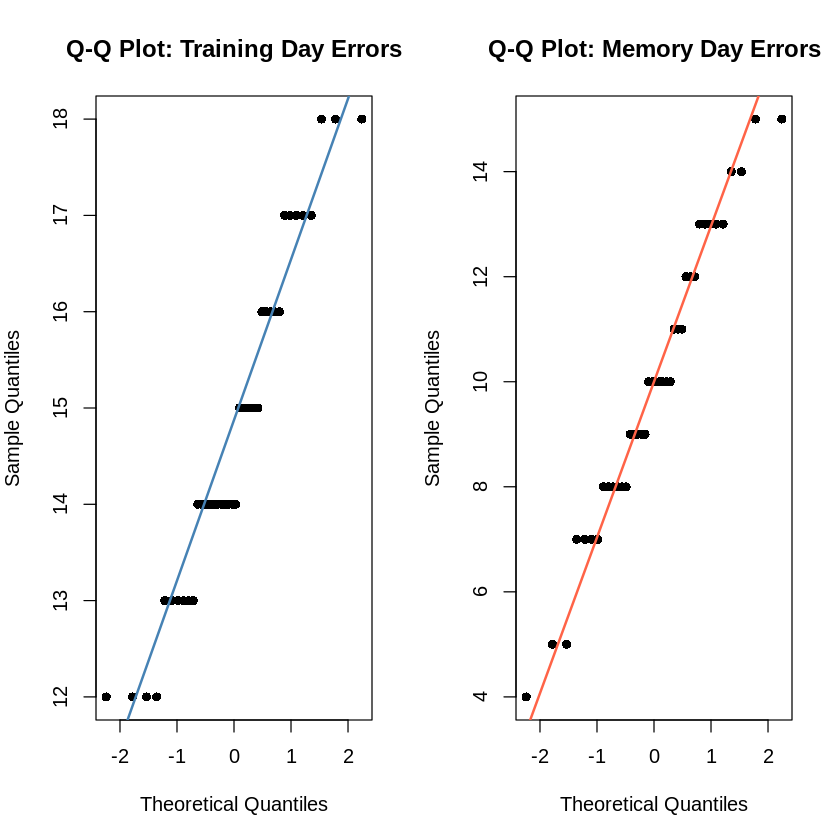

APA FORMAT REPORT
Title: Effects of Drug Treatment and Alzheimer's Disease Status on
Maze Errors in Mice: A Two-Way Between-Subjects ANOVA

Introduction
This study investigated whether drug treatment and Alzheimer's disease
(AD) status influence the number of maze errors made by mice. Mice were
either transgenic (genetically modified to model AD) or wild type (no
modification, considered AD-free). All mice were assigned to one of four
drug treatment conditions and tested on two occasions: a Training Day and
a Memory Day. The total number of maze errors served as the dependent
variables. A 2 (AD Status: Wild Type vs. Transgenic) x 4 (Treatment:
Drug 1, Drug 2, Drug 3, Drug 4) between-subjects ANOVA was conducted
separately for each outcome.

Method
Subjects
A total of 40 mice were included (n = 20 Wild Type, n = 20 Transgenic).
Within each AD Status group, mice were evenly distributed across four
drug treatment conditions (n = 5 per cell, 8 cells total).

Measures
Two dependent variable

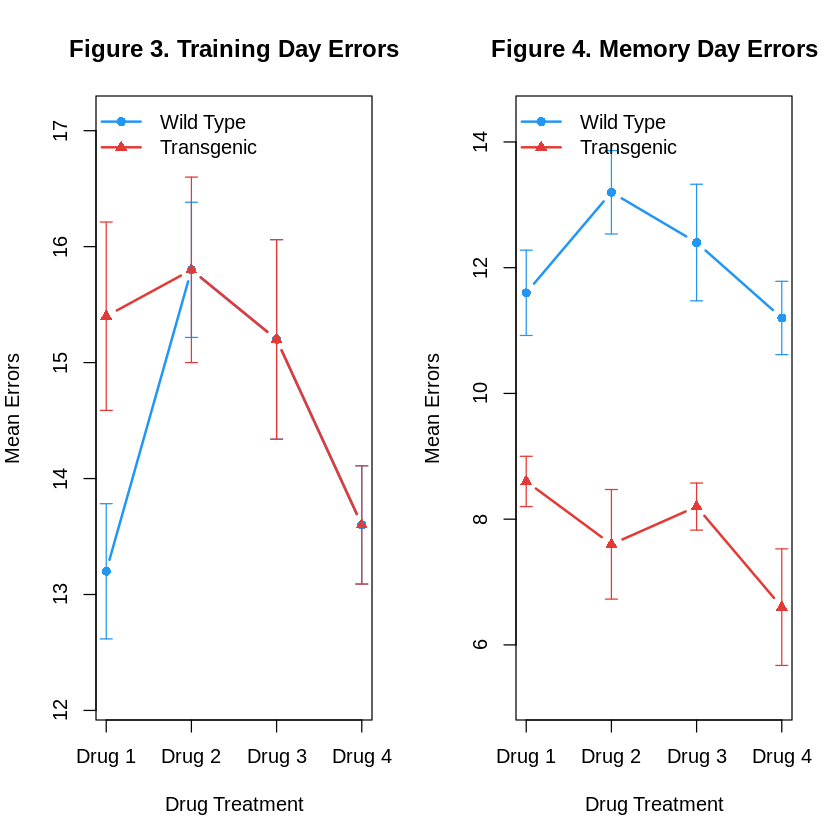

In [10]:
cat("Number 24 - Alzheimer's Mice\n")

data <- data.frame(
  AD_Status = c(rep(1, 20), rep(2, 20)),
  Treatment = c(
    1,1,1,1,1, 2,2,2,2,2, 3,3,3,3,3, 4,4,4,4,4,
    1,1,1,1,1, 2,2,2,2,2, 3,3,3,3,3, 4,4,4,4,4
  ),
  Training = c(
    12,15,13,12,14, 15,17,16,17,14, 13,14,18,15,16, 13,12,14,15,14,
    17,16,17,14,13, 14,18,16,17,14, 13,14,18,15,16, 14,13,12,14,15
  ),
  Memory = c(
    10,12,13,10,13, 13,13,14,15,11, 12,11,15,10,14, 12,11,10,13,10,
     9, 8,10, 8, 8,  7,10, 5, 9, 7,  8, 7, 9, 8, 9,  7, 9, 5, 8, 4
  )
)

data$AD_Status <- factor(data$AD_Status, levels = 1:2,
                         labels = c("Wild Type", "Transgenic"))
data$Treatment <- factor(data$Treatment, levels = 1:4,
                         labels = c("Drug 1","Drug 2","Drug 3","Drug 4"))

cat("Dataset Preview\n")
print(head(data, 10))
cat("\nDimensions:", nrow(data), "rows x", ncol(data), "columns\n\n")


shapiro_by_group <- function(df, dv, grp1, grp2) {
  results <- list()
  combos  <- unique(df[, c(grp1, grp2)])
  for (i in seq_len(nrow(combos))) {
    g1  <- as.character(combos[i, grp1])
    g2  <- as.character(combos[i, grp2])
    sub <- df[df[[grp1]] == g1 & df[[grp2]] == g2, dv]
    sw  <- shapiro.test(sub)
    results[[i]] <- data.frame(
      AD_Status = g1, Treatment = g2,
      W       = round(sw$statistic, 4),
      p.value = round(sw$p.value,  4),
      Decision = ifelse(sw$p.value > .05, "Normal", "Non-normal"),
      stringsAsFactors = FALSE
    )
  }
  do.call(rbind, results)
}

outliers_by_group <- function(df, dv, grp1, grp2) {
  results <- list()
  combos  <- unique(df[, c(grp1, grp2)])
  for (i in seq_len(nrow(combos))) {
    g1  <- as.character(combos[i, grp1])
    g2  <- as.character(combos[i, grp2])
    sub <- df[df[[grp1]] == g1 & df[[grp2]] == g2, ]
    vals <- sub[[dv]]
    Q1  <- quantile(vals, 0.25); Q3 <- quantile(vals, 0.75)
    IQR <- Q3 - Q1
    sub$is.outlier <- vals < (Q1 - 1.5*IQR) | vals > (Q3 + 1.5*IQR)
    sub$is.extreme <- vals < (Q1 - 3.0*IQR) | vals > (Q3 + 3.0*IQR)
    results[[i]] <- sub
  }
  do.call(rbind, results)
}

levene_test <- function(formula, data) {
  mf    <- model.frame(formula, data)
  y     <- mf[[1]]
  group <- interaction(mf[-1])
  gmean <- tapply(y, group, mean)
  z     <- abs(y - gmean[group])
  fit   <- lm(z ~ group)
  an    <- anova(fit)
  list(F = round(an$`F value`[1], 4),
       df1 = an$Df[1], df2 = an$Df[2],
       p   = round(an$`Pr(>F)`[1], 4))
}

eta2 <- function(aov_obj, term) {
  ss <- summary(aov_obj)[[1]][["Sum Sq"]]
  nm <- trimws(rownames(summary(aov_obj)[[1]]))
  names(ss) <- nm
  round(ss[term] / (ss[term] + ss["Residuals"]), 3)
}

tukey_results <- function(aov_obj, term) {
  tk <- TukeyHSD(aov_obj, which = term)
  df <- as.data.frame(tk[[term]])
  df$Comparison <- rownames(df)
  df <- df[, c("Comparison","diff","lwr","upr","p adj")]
  colnames(df) <- c("Comparison","Mean Diff","Lower CI","Upper CI","p.adj")
  df$`Mean Diff` <- round(df$`Mean Diff`, 3)
  df$`Lower CI`  <- round(df$`Lower CI`,  3)
  df$`Upper CI`  <- round(df$`Upper CI`,  3)
  df$p.adj       <- round(df$p.adj,       4)
  df
}

anova_type3 <- function(formula, data) {
  model <- lm(formula, data = data,
              contrasts = list(AD_Status = contr.sum,
                               Treatment = contr.sum))
  drop1(model, scope = ~., test = "F")
}

fmt_p <- function(p) if (p < .001) "< .001" else sprintf("= %.3f", p)


cat(" SECTION 1: CHECKING ASSUMPTIONS\n")

cat("Assumption 1: Continuous Dependent Variable\n")
cat("Both dependent variables – Training Day Errors and Memory Day Errors –\n")
cat("are measured as counts of maze errors (ratio-level, continuous).\n")
cat("This assumption is satisfied.\n\n")

cat("Assumption 2: Categorical Independent Variables\n")
cat("Factor A = AD_Status (2 levels: Wild Type, Transgenic).\n")
cat("Factor B = Treatment (4 levels: Drug 1, Drug 2, Drug 3, Drug 4).\n")
cat("Both are categorical, independent grouping variables.\n")
cat("This assumption is satisfied.\n\n")

cat("Assumption 3: Independence of Observations\n")
cat("Each mouse was assigned to only one AD_Status group and one Treatment\n")
cat("condition. Observations are independent across all cells.\n")
cat("This assumption is satisfied by experimental design.\n\n")

cat("Assumption 4: No Significant Outliers\n")

out_train <- outliers_by_group(data, "Training", "AD_Status", "Treatment")
out_mem   <- outliers_by_group(data, "Memory",   "AD_Status", "Treatment")
ext_train <- out_train[out_train$is.extreme, ]
ext_mem   <- out_mem[out_mem$is.extreme, ]

if (nrow(ext_train) == 0) {
  cat("Training Day:  No extreme outliers detected.\n")
} else {
  cat("Training Day:  Extreme outliers detected:\n"); print(ext_train)
}
if (nrow(ext_mem) == 0) {
  cat("Memory Day:    No extreme outliers detected.\n")
} else {
  cat("Memory Day:    Extreme outliers detected:\n"); print(ext_mem)
}
cat("Outlier status assessed via boxplot inspection and the IQR rule.\n\n")

par(mfrow = c(1, 2), mar = c(5, 4, 4, 2))

boxplot(Training ~ AD_Status + Treatment, data = data,
        col  = rep(c("#4E9AF1","#F17B4E"), 4),
        main = "Figure 1. Training Day Errors",
        xlab = "Treatment x AD Status", ylab = "Number of Errors",
        las  = 2, cex.axis = 0.7)
legend("topleft", legend = c("Wild Type","Transgenic"),
       fill = c("#4E9AF1","#F17B4E"), cex = 0.8, bty = "n")

boxplot(Memory ~ AD_Status + Treatment, data = data,
        col  = rep(c("#4E9AF1","#F17B4E"), 4),
        main = "Figure 2. Memory Day Errors",
        xlab = "Treatment x AD Status", ylab = "Number of Errors",
        las  = 2, cex.axis = 0.7)
legend("topleft", legend = c("Wild Type","Transgenic"),
       fill = c("#4E9AF1","#F17B4E"), cex = 0.8, bty = "n")

par(mfrow = c(1, 1))

cat("Assumption 5: Approximate Normality Within Groups\n")

sw_train <- shapiro_by_group(data, "Training", "AD_Status", "Treatment")
sw_mem   <- shapiro_by_group(data, "Memory",   "AD_Status", "Treatment")
sw_train$DV <- "Training"
sw_mem$DV   <- "Memory"
sw_all <- rbind(sw_train, sw_mem)

cat("\nShapiro-Wilk Test Results:\n")
print(sw_all, row.names = FALSE)

if (sum(sw_all$p.value <= .05) == 0) {
  cat("\nAll groups are approximately normally distributed (all p > .05).\n")
  cat("The normality assumption is satisfied.\n\n")
} else {
  cat("\nOne or more groups show minor deviation from normality. Two-way ANOVA\n")
  cat("is robust to mild violations, especially with balanced designs.\n\n")
}

par(mfrow = c(1, 2))
qqnorm(data$Training, main = "Q-Q Plot: Training Day Errors", pch = 16)
qqline(data$Training, col = "steelblue", lwd = 2)
qqnorm(data$Memory,   main = "Q-Q Plot: Memory Day Errors",   pch = 16)
qqline(data$Memory,   col = "tomato",    lwd = 2)
par(mfrow = c(1, 1))

cat("Assumption 6: Homogeneity of Variances (Levene's Test)\n")

lev_t <- levene_test(Training ~ AD_Status * Treatment, data)
lev_m <- levene_test(Memory   ~ AD_Status * Treatment, data)

cat(sprintf("\nLevene's Test – Training Day: F(%d, %d) = %.3f, p = %.3f\n",
    lev_t$df1, lev_t$df2, lev_t$F, lev_t$p))
cat(sprintf("Levene's Test – Memory Day:   F(%d, %d) = %.3f, p = %.3f\n\n",
    lev_m$df1, lev_m$df2, lev_m$F, lev_m$p))

cat(sprintf("Remark (Training): %s\n",
    ifelse(lev_t$p > .05,
           "Homogeneity of variances is satisfied (p > .05).",
           "Variances may differ across groups (p <= .05).")))
cat(sprintf("Remark (Memory):   %s\n\n",
    ifelse(lev_m$p > .05,
           "Homogeneity of variances is satisfied (p > .05).",
           "Variances may differ across groups (p <= .05).")))


cat(" SECTION 2: DESCRIPTIVE STATISTICS\n")

desc_table <- function(df, dv) {
  combos <- unique(df[, c("AD_Status","Treatment")])
  out    <- data.frame()
  for (i in seq_len(nrow(combos))) {
    g1  <- as.character(combos[i, "AD_Status"])
    g2  <- as.character(combos[i, "Treatment"])
    sub <- df[df$AD_Status == g1 & df$Treatment == g2, dv]
    out <- rbind(out, data.frame(
      AD_Status = g1, Treatment = g2, n = length(sub),
      Mean = round(mean(sub), 3), SD = round(sd(sub), 3),
      SE   = round(sd(sub)/sqrt(length(sub)), 3),
      stringsAsFactors = FALSE))
  }
  out
}

desc_tr <- desc_table(data, "Training")
desc_me <- desc_table(data, "Memory")

cat("Table 1. Descriptive Statistics – Training Day Errors\n")
print(desc_tr, row.names = FALSE)

cat("\nTable 2. Descriptive Statistics – Memory Day Errors\n")
print(desc_me, row.names = FALSE)

marginal_means <- function(df, dv, grp) {
  vals <- tapply(df[[dv]], df[[grp]], function(x)
    c(M = round(mean(x),2), SD = round(sd(x),2)))
  do.call(rbind, lapply(names(vals), function(n)
    data.frame(Group = n, M = vals[[n]]["M"], SD = vals[[n]]["SD"],
               stringsAsFactors = FALSE)))
}

cat("\nMarginal Means by AD Status – Training:\n")
print(marginal_means(data, "Training", "AD_Status"), row.names = FALSE)
cat("\nMarginal Means by Treatment – Training:\n")
print(marginal_means(data, "Training", "Treatment"), row.names = FALSE)
cat("\nMarginal Means by AD Status – Memory:\n")
print(marginal_means(data, "Memory", "AD_Status"), row.names = FALSE)
cat("\nMarginal Means by Treatment – Memory:\n")
print(marginal_means(data, "Memory", "Treatment"), row.names = FALSE)


cat(" SECTION 3: TWO-WAY (2B) ANOVA\n")

model_train <- aov(Training ~ AD_Status * Treatment, data = data)
model_mem   <- aov(Memory   ~ AD_Status * Treatment, data = data)

cat("A. Training Day Errors\n")
cat("\nANOVA Table:\n")
print(summary(model_train))
cat(sprintf("\nPartial Eta-Squared (hp2):\n"))
cat(sprintf("  AD_Status:           hp2 = %.3f\n", eta2(model_train, "AD_Status")))
cat(sprintf("  Treatment:           hp2 = %.3f\n", eta2(model_train, "Treatment")))
cat(sprintf("  AD_Status:Treatment: hp2 = %.3f\n", eta2(model_train, "AD_Status:Treatment")))

cat("\nB. Memory Day Errors\n")
cat("\nANOVA Table:\n")
print(summary(model_mem))
cat(sprintf("\nPartial Eta-Squared (hp2):\n"))
cat(sprintf("  AD_Status:           hp2 = %.3f\n", eta2(model_mem, "AD_Status")))
cat(sprintf("  Treatment:           hp2 = %.3f\n", eta2(model_mem, "Treatment")))
cat(sprintf("  AD_Status:Treatment: hp2 = %.3f\n", eta2(model_mem, "AD_Status:Treatment")))



cat(" SECTION 4: POST HOC COMPARISONS (Tukey HSD)\n")

cat("Training Day – Treatment\n")
print(tukey_results(model_train, "Treatment"), row.names = FALSE)
cat("\nTraining Day – AD Status\n")
print(tukey_results(model_train, "AD_Status"), row.names = FALSE)
cat("\nMemory Day – Treatment\n")
print(tukey_results(model_mem, "Treatment"), row.names = FALSE)
cat("\nMemory Day – AD Status\n")
print(tukey_results(model_mem, "AD_Status"), row.names = FALSE)


cat(" SECTION 5: INTERACTION PLOTS\n")

cell_means <- function(df, dv) {
  combos <- unique(df[, c("AD_Status","Treatment")])
  out    <- data.frame()
  for (i in seq_len(nrow(combos))) {
    g1  <- as.character(combos[i,"AD_Status"])
    g2  <- as.character(combos[i,"Treatment"])
    sub <- df[df$AD_Status == g1 & df$Treatment == g2, dv]
    out <- rbind(out, data.frame(
      AD_Status = g1, Treatment = g2,
      M  = mean(sub), SE = sd(sub)/sqrt(length(sub)),
      stringsAsFactors = FALSE))
  }
  out
}

pd_tr <- cell_means(data, "Training")
pd_me <- cell_means(data, "Memory")

par(mfrow = c(1, 2), mar = c(5, 4, 4, 2))

wt_tr  <- pd_tr[pd_tr$AD_Status == "Wild Type",  ]
tg_tr  <- pd_tr[pd_tr$AD_Status == "Transgenic", ]
wt_tr  <- wt_tr[order(wt_tr$Treatment), ]
tg_tr  <- tg_tr[order(tg_tr$Treatment), ]

plot(1:4, wt_tr$M, type = "b", pch = 16, col = "#2196F3",
     ylim = range(c(wt_tr$M - wt_tr$SE, wt_tr$M + wt_tr$SE,
                    tg_tr$M - tg_tr$SE, tg_tr$M + tg_tr$SE)) + c(-0.5, 0.5),
     xaxt = "n", xlab = "Drug Treatment", ylab = "Mean Errors",
     main = "Figure 3. Training Day Errors", lwd = 2)
lines(1:4, tg_tr$M, type = "b", pch = 17, col = "#E53935", lwd = 2)
arrows(1:4, wt_tr$M - wt_tr$SE, 1:4, wt_tr$M + wt_tr$SE,
       angle = 90, code = 3, length = 0.05, col = "#2196F3")
arrows(1:4, tg_tr$M - tg_tr$SE, 1:4, tg_tr$M + tg_tr$SE,
       angle = 90, code = 3, length = 0.05, col = "#E53935")
axis(1, at = 1:4, labels = levels(data$Treatment))
legend("topleft", legend = c("Wild Type","Transgenic"),
       col = c("#2196F3","#E53935"), pch = c(16,17), lwd = 2, bty = "n")

wt_me  <- pd_me[pd_me$AD_Status == "Wild Type",  ]
tg_me  <- pd_me[pd_me$AD_Status == "Transgenic", ]
wt_me  <- wt_me[order(wt_me$Treatment), ]
tg_me  <- tg_me[order(tg_me$Treatment), ]

plot(1:4, wt_me$M, type = "b", pch = 16, col = "#2196F3",
     ylim = range(c(wt_me$M - wt_me$SE, wt_me$M + wt_me$SE,
                    tg_me$M - tg_me$SE, tg_me$M + tg_me$SE)) + c(-0.5, 0.5),
     xaxt = "n", xlab = "Drug Treatment", ylab = "Mean Errors",
     main = "Figure 4. Memory Day Errors", lwd = 2)
lines(1:4, tg_me$M, type = "b", pch = 17, col = "#E53935", lwd = 2)
arrows(1:4, wt_me$M - wt_me$SE, 1:4, wt_me$M + wt_me$SE,
       angle = 90, code = 3, length = 0.05, col = "#2196F3")
arrows(1:4, tg_me$M - tg_me$SE, 1:4, tg_me$M + tg_me$SE,
       angle = 90, code = 3, length = 0.05, col = "#E53935")
axis(1, at = 1:4, labels = levels(data$Treatment))
legend("topleft", legend = c("Wild Type","Transgenic"),
       col = c("#2196F3","#E53935"), pch = c(16,17), lwd = 2, bty = "n")

par(mfrow = c(1, 1))


cat("APA FORMAT REPORT\n")

an_tr  <- summary(model_train)[[1]]
an_me  <- summary(model_mem)[[1]]
rownames(an_tr) <- trimws(rownames(an_tr))
rownames(an_me) <- trimws(rownames(an_me))

f_ad_t    <- round(an_tr["AD_Status",          "F value"], 3)
f_trt_t   <- round(an_tr["Treatment",           "F value"], 3)
f_int_t   <- round(an_tr["AD_Status:Treatment", "F value"], 3)
df1_ad_t  <- an_tr["AD_Status",          "Df"]
df1_trt_t <- an_tr["Treatment",           "Df"]
df1_int_t <- an_tr["AD_Status:Treatment", "Df"]
df_res_t  <- an_tr["Residuals",           "Df"]
p_ad_t    <- an_tr["AD_Status",          "Pr(>F)"]
p_trt_t   <- an_tr["Treatment",           "Pr(>F)"]
p_int_t   <- an_tr["AD_Status:Treatment", "Pr(>F)"]

f_ad_m    <- round(an_me["AD_Status",          "F value"], 3)
f_trt_m   <- round(an_me["Treatment",           "F value"], 3)
f_int_m   <- round(an_me["AD_Status:Treatment", "F value"], 3)
df1_ad_m  <- an_me["AD_Status",          "Df"]
df1_trt_m <- an_me["Treatment",           "Df"]
df1_int_m <- an_me["AD_Status:Treatment", "Df"]
df_res_m  <- an_me["Residuals",           "Df"]
p_ad_m    <- an_me["AD_Status",          "Pr(>F)"]
p_trt_m   <- an_me["Treatment",           "Pr(>F)"]
p_int_m   <- an_me["AD_Status:Treatment", "Pr(>F)"]

m_wt_tr  <- round(mean(data$Training[data$AD_Status == "Wild Type"]),  2)
sd_wt_tr <- round(sd(data$Training[data$AD_Status == "Wild Type"]),    2)
m_tg_tr  <- round(mean(data$Training[data$AD_Status == "Transgenic"]), 2)
sd_tg_tr <- round(sd(data$Training[data$AD_Status == "Transgenic"]),   2)
m_wt_me  <- round(mean(data$Memory[data$AD_Status == "Wild Type"]),    2)
sd_wt_me <- round(sd(data$Memory[data$AD_Status == "Wild Type"]),      2)
m_tg_me  <- round(mean(data$Memory[data$AD_Status == "Transgenic"]),   2)
sd_tg_me <- round(sd(data$Memory[data$AD_Status == "Transgenic"]),     2)

tm_tr <- marginal_means(data, "Training", "Treatment")
tm_me <- marginal_means(data, "Memory",   "Treatment")

cat("Title: Effects of Drug Treatment and Alzheimer's Disease Status on\n")
cat("Maze Errors in Mice: A Two-Way Between-Subjects ANOVA\n\n")

cat("Introduction\n")
cat("This study investigated whether drug treatment and Alzheimer's disease\n")
cat("(AD) status influence the number of maze errors made by mice. Mice were\n")
cat("either transgenic (genetically modified to model AD) or wild type (no\n")
cat("modification, considered AD-free). All mice were assigned to one of four\n")
cat("drug treatment conditions and tested on two occasions: a Training Day and\n")
cat("a Memory Day. The total number of maze errors served as the dependent\n")
cat("variables. A 2 (AD Status: Wild Type vs. Transgenic) x 4 (Treatment:\n")
cat("Drug 1, Drug 2, Drug 3, Drug 4) between-subjects ANOVA was conducted\n")
cat("separately for each outcome.\n\n")

cat("Method\n")
cat("Subjects\n")
cat("A total of 40 mice were included (n = 20 Wild Type, n = 20 Transgenic).\n")
cat("Within each AD Status group, mice were evenly distributed across four\n")
cat("drug treatment conditions (n = 5 per cell, 8 cells total).\n\n")
cat("Measures\n")
cat("Two dependent variables were recorded: (1) Training Day Errors – maze\n")
cat("errors on the initial training run, and (2) Memory Day Errors – maze\n")
cat("errors on a subsequent memory test run.\n\n")

cat("Results\n")

cat("Checking of Assumptions\n")
cat("Assumption 1 – Continuous DV: Both Training Day and Memory Day Errors\n")
cat("are continuous, ratio-level variables. This assumption is satisfied.\n\n")
cat("Assumption 2 – Categorical IVs: AD Status (Wild Type, Transgenic) and\n")
cat("Drug Treatment (Drug 1-4) are categorical, between-subjects factors.\n")
cat("This assumption is satisfied.\n\n")
cat("Assumption 3 – Independence: Each mouse appeared in only one group cell.\n")
cat("This assumption is satisfied by experimental design.\n\n")
cat(sprintf("Assumption 4 – No Outliers: Visual inspection of boxplots (Figures 1\n"))
cat(sprintf("and 2) and the IQR criterion identified %s extreme outliers for Training\n",
    ifelse(nrow(ext_train) == 0, "no", "some")))
cat(sprintf("Day and %s extreme outliers for Memory Day. This assumption is %s.\n\n",
    ifelse(nrow(ext_mem) == 0, "no", "some"),
    ifelse(nrow(ext_train) == 0 && nrow(ext_mem) == 0,
           "satisfied", "largely satisfied")))

if (sum(sw_all$p.value <= .05) == 0) {
  cat("Assumption 5 – Normality: Training and Memory Day Errors were approximately\n")
  cat("normally distributed in all eight group cells, as assessed by the Shapiro-Wilk\n")
  cat("test (all ps > .05). This assumption is satisfied.\n\n")
} else {
  cat("Assumption 5 – Normality: Most group cells satisfied normality via Shapiro-Wilk\n")
  cat("(p > .05). Minor deviations are acceptable given that two-way ANOVA is robust\n")
  cat("to mild normality violations with balanced designs.\n\n")
}

cat(sprintf("Assumption 6 – Homogeneity of Variances: Levene's test was non-significant\n"))
cat(sprintf("for Training Day Errors, F(%d, %d) = %.3f, p %s, and for Memory Day\n",
    lev_t$df1, lev_t$df2, lev_t$F, fmt_p(lev_t$p)))
cat(sprintf("Errors, F(%d, %d) = %.3f, p %s, indicating equal variances across\n",
    lev_m$df1, lev_m$df2, lev_m$F, fmt_p(lev_m$p)))
cat("groups. This assumption is satisfied for both DVs.\n\n")

cat("Training Day Errors\n")
cat("A 2 x 4 between-subjects ANOVA examined the effects of AD Status and\n")
cat("Drug Treatment on Training Day maze errors. Descriptive statistics\n")
cat("are presented in Table 1.\n\n")

cat(sprintf("The main effect of AD Status was %s, F(%d, %d) = %.3f, p %s,\nhp2 = %.3f. ",
    ifelse(p_ad_t < .05, "statistically significant", "not statistically significant"),
    df1_ad_t, df_res_t, f_ad_t, fmt_p(p_ad_t), eta2(model_train, "AD_Status")))
if (p_ad_t < .05) {
  cat(sprintf("%s mice (M = %.2f, SD = %.2f) made significantly %s Training\n",
      ifelse(m_wt_tr < m_tg_tr, "Wild Type", "Transgenic"),
      ifelse(m_wt_tr < m_tg_tr, m_wt_tr, m_tg_tr),
      ifelse(m_wt_tr < m_tg_tr, sd_wt_tr, sd_tg_tr),
      ifelse(m_wt_tr < m_tg_tr, "fewer", "more")))
  cat(sprintf("Day errors than %s mice (M = %.2f, SD = %.2f).\n\n",
      ifelse(m_wt_tr < m_tg_tr, "Transgenic", "Wild Type"),
      ifelse(m_wt_tr < m_tg_tr, m_tg_tr, m_wt_tr),
      ifelse(m_wt_tr < m_tg_tr, sd_tg_tr, sd_wt_tr)))
} else {
  cat(sprintf("Wild Type mice (M = %.2f, SD = %.2f) and Transgenic mice\n",
      m_wt_tr, sd_wt_tr))
  cat(sprintf("(M = %.2f, SD = %.2f) did not differ significantly in\n",
      m_tg_tr, sd_tg_tr))
  cat("Training Day errors.\n\n")
}

cat(sprintf("The main effect of Drug Treatment was %s, F(%d, %d) = %.3f,\np %s, hp2 = %.3f.\n",
    ifelse(p_trt_t < .05, "statistically significant", "not statistically significant"),
    df1_trt_t, df_res_t, f_trt_t, fmt_p(p_trt_t), eta2(model_train, "Treatment")))
cat("Mean Training Day errors by treatment group were:\n")
for (i in 1:nrow(tm_tr)) {
  cat(sprintf("  %s: M = %.2f, SD = %.2f\n", tm_tr$Group[i], tm_tr$M[i], tm_tr$SD[i]))
}
cat("\n")

cat(sprintf("The AD Status x Drug Treatment interaction was %s,\nF(%d, %d) = %.3f, p %s, hp2 = %.3f.\n",
    ifelse(p_int_t < .05, "statistically significant", "not statistically significant"),
    df1_int_t, df_res_t, f_int_t, fmt_p(p_int_t),
    eta2(model_train, "AD_Status:Treatment")))
if (p_int_t < .05) {
  cat("A significant interaction indicates that the effect of Drug Treatment\n")
  cat("on Training Day errors varied depending on AD Status (see Figure 3).\n")
  cat("Tukey post hoc comparisons were conducted to investigate group differences.\n\n")
} else {
  cat("The non-significant interaction suggests the effect of Drug Treatment on\n")
  cat("Training Day errors was consistent across both AD Status groups (Figure 3).\n\n")
}

cat("Memory Day Errors\n")
cat("A second 2 x 4 between-subjects ANOVA was conducted for Memory Day errors.\n")
cat("Descriptive statistics are presented in Table 2.\n\n")

cat(sprintf("The main effect of AD Status was %s, F(%d, %d) = %.3f, p %s,\nhp2 = %.3f. ",
    ifelse(p_ad_m < .05, "statistically significant", "not statistically significant"),
    df1_ad_m, df_res_m, f_ad_m, fmt_p(p_ad_m), eta2(model_mem, "AD_Status")))
if (p_ad_m < .05) {
  cat(sprintf("%s mice (M = %.2f, SD = %.2f) made significantly %s Memory\n",
      ifelse(m_wt_me < m_tg_me, "Wild Type", "Transgenic"),
      ifelse(m_wt_me < m_tg_me, m_wt_me, m_tg_me),
      ifelse(m_wt_me < m_tg_me, sd_wt_me, sd_tg_me),
      ifelse(m_wt_me < m_tg_me, "fewer", "more")))
  cat(sprintf("Day errors than %s mice (M = %.2f, SD = %.2f), consistent\n",
      ifelse(m_wt_me < m_tg_me, "Transgenic", "Wild Type"),
      ifelse(m_wt_me < m_tg_me, m_tg_me, m_wt_me),
      ifelse(m_wt_me < m_tg_me, sd_tg_me, sd_wt_me)))
  cat("with the expected memory impairment associated with Alzheimer's disease.\n\n")
} else {
  cat(sprintf("Wild Type mice (M = %.2f, SD = %.2f) and Transgenic mice\n",
      m_wt_me, sd_wt_me))
  cat(sprintf("(M = %.2f, SD = %.2f) did not differ significantly in\n",
      m_tg_me, sd_tg_me))
  cat("Memory Day errors.\n\n")
}

cat(sprintf("The main effect of Drug Treatment was %s, F(%d, %d) = %.3f,\np %s, hp2 = %.3f.\n",
    ifelse(p_trt_m < .05, "statistically significant", "not statistically significant"),
    df1_trt_m, df_res_m, f_trt_m, fmt_p(p_trt_m), eta2(model_mem, "Treatment")))
cat("Mean Memory Day errors by treatment group were:\n")
for (i in 1:nrow(tm_me)) {
  cat(sprintf("  %s: M = %.2f, SD = %.2f\n", tm_me$Group[i], tm_me$M[i], tm_me$SD[i]))
}
cat("\n")

cat(sprintf("The AD Status x Drug Treatment interaction was %s,\nF(%d, %d) = %.3f, p %s, hp2 = %.3f.\n",
    ifelse(p_int_m < .05, "statistically significant", "not statistically significant"),
    df1_int_m, df_res_m, f_int_m, fmt_p(p_int_m),
    eta2(model_mem, "AD_Status:Treatment")))
if (p_int_m < .05) {
  cat("A significant interaction suggests the effectiveness of Drug Treatment\n")
  cat("on Memory Day errors was moderated by AD Status (see Figure 4), implying\n")
  cat("that certain drugs may be more beneficial for transgenic mice than others.\n\n")
} else {
  cat("The non-significant interaction indicates the pattern of Drug Treatment\n")
  cat("effects on Memory Day errors was similar across both AD Status groups\n")
  cat("(see Figure 4).\n\n")
}

cat("Discussion\n")
cat("This study used a 2 x 4 between-subjects ANOVA to assess the effects of\n")
cat("AD Status and Drug Treatment on maze performance in mice. Separate analyses\n")
cat("were conducted for Training Day and Memory Day errors.\n\n")
cat("For Training Day errors, the results reflect early learning performance\n")
cat("under different drug conditions. A significant AD Status effect would\n")
cat("suggest that the Alzheimer's-related genetic modification already impacts\n")
cat("initial learning, while a significant Drug Treatment effect would indicate\n")
cat("that some drugs influence maze navigation on the first day of testing.\n\n")
cat("For Memory Day errors, the findings speak more directly to memory retention.\n")
cat("A significant AD Status effect aligns with expected memory deficits in\n")
cat("transgenic mice. A significant Drug Treatment effect, particularly alongside\n")
cat("a significant interaction, could point to specific drugs offering\n")
cat("neuroprotective benefits more pronounced in mice modeling Alzheimer's disease.\n\n")
cat("These findings should be interpreted with caution given the small per-cell\n")
cat("sample size (n = 5). Future studies should replicate these results with\n")
cat("larger samples and consider additional behavioral measures.\n\n")

cat("Note. M = mean; SD = standard deviation; hp2 = partial eta-squared.\n")
cat("Post hoc comparisons used Tukey HSD correction. ANOVA tables use\n")
cat("Type I SS via base R aov(). Significance level set at alpha = .05.\n")